In [10]:
!pip install pandas numpy scipy scikit-learn openpyxl matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift, DBSCAN
from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [12]:
insurance_dataset = pd.read_excel(r"C:\Users\amros\OneDrive\Desktop\clustering\data\Sample -superstores.xls")

In [23]:
# 1. First 5 rows
insurance_dataset.head()

# 2. Last 5 rows
insurance_dataset.tail()

# 3. Number of rows and columns
insurance_dataset.shape

# 4. Column names
insurance_dataset.columns

# 5. Data types
insurance_dataset.dtypes

# 6. Complete information
insurance_dataset.info()

# 7. Statistical summary
insurance_dataset.describe()

# 8. Missing values
insurance_dataset.isna().sum()

# 9. Missing values percentage
insurance_dataset.isna().mean() * 100

# 10. Duplicate rows
insurance_dataset.duplicated().sum()

# 11. Number of unique values
insurance_dataset.nunique()

# 12. Unique values of a column
insurance_dataset['CODE_GENDER'].unique()

# 13. Value counts
insurance_dataset['CODE_GENDER'].value_counts()

# 14. Check null values
insurance_dataset.isnull().sum()

# 15. Check dataset size
insurance_dataset.size

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

KeyError: 'CODE_GENDER'

In [ ]:
insurance_dataset=insurance_dataset[['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','CNT_FAM_MEMBERS']]

In [ ]:
insurance_dataset.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_REQ_CREDIT_BUREAU_YEAR.1,Unnamed: 122
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0000
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,2.0000
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0.0,0.0,0.0,0.0,1.0,4.0,NaN,2.0000
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,26.0000
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,516740.4356


In [ ]:
insurance_dataset.shape

(48744, 123)

In [ ]:
insurance_dataset.isna().sum()

SK_ID_CURR                          0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                        0
FLAG_OWN_REALTY                     0
                                ...  
AMT_REQ_CREDIT_BUREAU_MON        6049
AMT_REQ_CREDIT_BUREAU_QRT        6049
AMT_REQ_CREDIT_BUREAU_YEAR       6049
AMT_REQ_CREDIT_BUREAU_YEAR.1    48744
Unnamed: 122                    48733
Length: 123, dtype: int64

In [ ]:
def fill_null_values(df):
    for column in df.columns:
        if df[column].isnull().sum() > 0:
            if df[column].dtype in ['int64', 'float64']:
                df[column] = df[column].fillna(df[column].median())
                
                return df

            insurance_dataset = insurance_dataset.fillna(insurance_dataset.mode().iloc[0])
            fill_null_values(insurance_dataset)
        

In [ ]:
insurance_dataset

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_REQ_CREDIT_BUREAU_YEAR.1,Unnamed: 122
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0000
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,2.0000
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0.0,0.0,0.0,0.0,1.0,4.0,NaN,2.0000
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,26.0000
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,516740.4356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0,0,0.0,0.0,0.0,0.0,3.0,1.0,NaN,NaN
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN


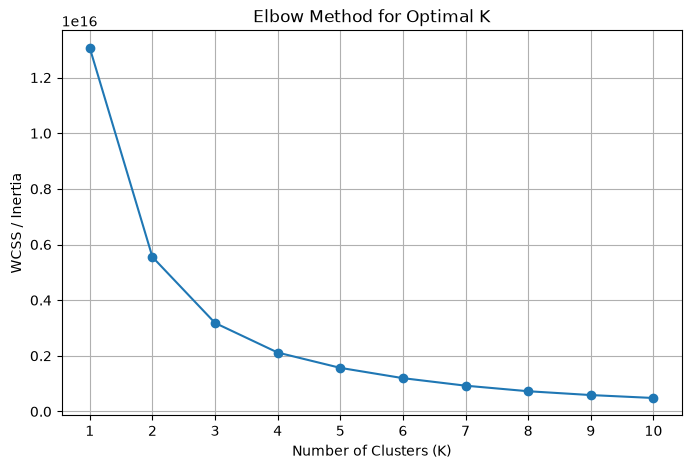

In [ ]:
# Select numerical features for clustering
X = insurance_dataset[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'CNT_FAM_MEMBERS'
    ]
]

# Handle missing values
X = X.fillna(X.median())

# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

In [24]:
from sklearn.preprocessing import StandardScaler

x = insurance_dataset.select_dtypes(include='number')

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(x_scaled.shape)

(10194, 5)


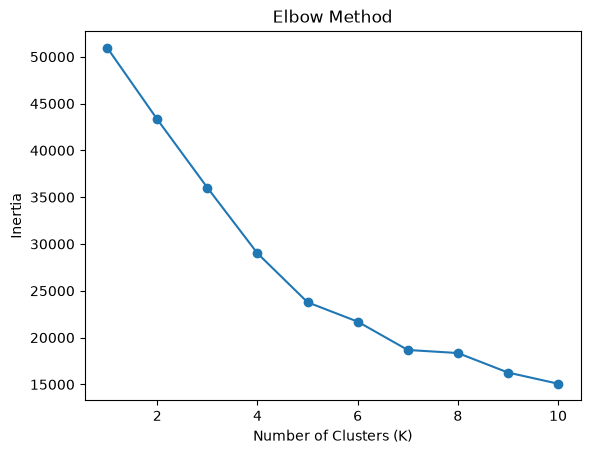

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [27]:
x_scaled[0:100]

array([[-1.73188091e+00, -3.41645274e-01, -8.04161327e-01,
         2.16329470e-01, -9.94701994e-02],
       [-1.73154109e+00, -3.62468779e-01, -8.04161327e-01,
         3.12558294e+00, -1.46955782e-01],
       [-1.73120127e+00, -3.49169355e-01, -3.55370099e-01,
         2.16329470e-01, -1.04974521e-01],
       [-1.73086145e+00,  7.18048692e-02, -3.55370099e-01,
         2.16329470e-01, -4.02007850e-01],
       [-1.73052164e+00, -3.36663636e-01, -3.55370099e-01,
         2.16329470e-01, -1.02340448e-01],
       [-1.73018182e+00,  3.78397052e+00,  2.33737727e+00,
        -7.53421687e-01,  3.08764431e+00],
       [-1.72984200e+00, -3.59339123e-01, -8.04161327e-01,
        -7.53421687e-01, -1.16985945e-01],
       [-1.72950218e+00, -3.47562583e-01, -3.55370099e-01,
        -7.53421687e-01, -1.00809821e-01],
       [-1.72916237e+00,  6.15855235e-01, -8.04161327e-01,
        -7.53421687e-01,  1.05749046e+00],
       [-1.72882255e+00, -3.17976041e-01,  9.34211287e-02,
        -7.53421687e-01